In [124]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from scipy.integrate import solve_bvp, simpson
import time

newparams = {'figure.figsize': (6.0, 6.0), 'axes.grid': True,
 'lines.markersize': 6, 'lines.linewidth': 2,
 'font.size': 10}
plt.rcParams.update(newparams)

## Problem 1

### 1a)

We have the second-order differential equation:

$$
    \frac{d^2 y}{dx^2} = -4 \sin(2x),
$$

with initial conditions:

$$
    y(0) = 0, \quad y'(0) = 2.
$$

First, we find the general solution. We start by integrating once,

$$
    \frac{dy}{dx} = \int -4 \sin(2x) \, dx
$$

$$
    = -4 \cdot \left(-\frac{1}{2} \cos(2x)\right) + C_1
$$

$$
    = 2 \cos(2x) + C_1.
$$

Then integrating again,

$$
    y = \int \left(2 \cos(2x) + C_1 \right) dx
$$

$$
    = 2 \cdot \frac{1}{2} \sin(2x) + C_1 x + C_2
$$

$$
    = \sin(2x) + C_1 x + C_2.
$$

Next we apply the initial conditions. Using $ y(0) = 0 $ we get

$$
    0 = \sin(0) + C_1(0) + C_2 \quad \Rightarrow \quad C_2 = 0.
$$

Using $ y'(0) = 2 $ we get

$$
    2 = 2 \cos(0) + C_1
$$

$$
    2 = 2(1) + C_1
$$

$$
    C_1 = 0.
$$

Thus, the solution to the initial value problem is

$$
    y(x) = \sin(2x).
$$


### 1b)

The first order differential equation is the following
$$\frac{d}{dx}\begin{bmatrix} y \\ y'\end{bmatrix} = \begin{pmatrix} y' \\ -4\sin\left(2x\right)\end{pmatrix},$$
with the initial condition $\vec{y}(0) = \begin{pmatrix} 0 \\ 2\end{pmatrix}$.

### 1c)

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def f(x,y):
    return np.array([y[1], -4*np.sin(2*x)])

x = 0.0
x_end = 2*np.pi
h = 0.1
tol = 10**(-7)
alpha = 0.8
y_init = np.array([0, 2])
y = y_init.copy()

x_list = [x]
y_list = [y[0]]
y_der = [y[1]]
h_list = []

while x < x_end:
    if x + h > x_end:
        h = x_end - x

    k1 = f(x, y)
    k2 = f(x + h/2, y + h*k1/2)
    k3 = f(x + 3*h/4, y + 3*h*k2/4)

    y_next = y + h*(2*k1 + 3*k2 + 4*k3)/9
    k4 = f(x + h, y_next)

    z_next = y + h*(7*k1 + 6*k2 + 8*k3 + 3*k4)/24
    est = np.linalg.norm(y_next - z_next)

    if est < tol:
        x = x + h
        y = y_next

        x_list.append(x)
        y_list.append(y[0])
        y_der.append(y[1])
        h_list.append(h)

    if est == 0:
        h = 2*h
    else:
        h = alpha*h*(tol/est)**(1/3)



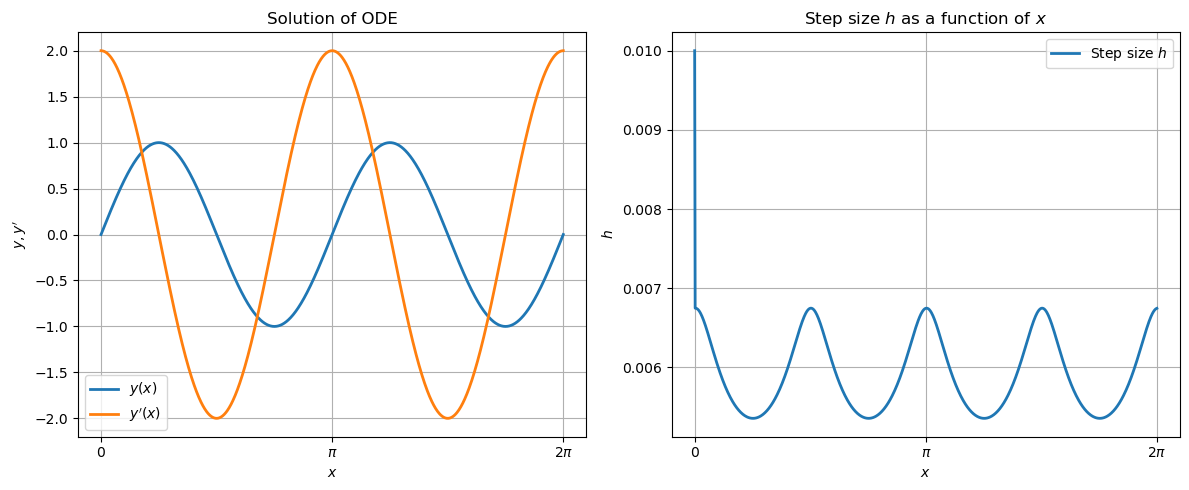

In [ ]:
plt.plot(x_list, y_list, label="y(x)", color = "hotpink")
plt.plot(x_list, y_der, label="y'(x)", color = "purple")
plt.xlabel("x")
plt.ylabel("y, y'")
plt.title("Løsning av førsteordens differensialligning")
plt.legend()
plt.grid()
plt.show()

plt.plot(x_list[:-1], h_list)
plt.title("Steglengdevariasjon")
plt.xlabel("x")
plt.ylabel("h")
plt.grid()
plt.show()

A decrease in $est_{n+1} = ||y_{n+1} - z_{n+1}||$ leads to an increase in $\frac{h_{new}}{h_n} = \alpha \cdot \left(\frac{tol}{est}\right)^{1/3}$. 
Since $y'(x)$ has greater amplitude than $y(x)$ and same periode, $est$ will be more affected by changes in $y'(x)$ than $y(x)$. Therefore the shape of the bottoms is similar as for $|y''(x)|^{-1}$. Because the change of $y(x)$ is greatest when the change of $y'(x)$ is low, the maximum step length has an upper bound.

Therefore the minimas of the step sizes are aligned with the turning points of $y'(x)$, in other words where it changes the most. Similarly the maximas are aligned with the turning points of $y(x)$, creating the upper bound as discussed. This repeats itself due to the periodic nature of the ODE.

### 1d)

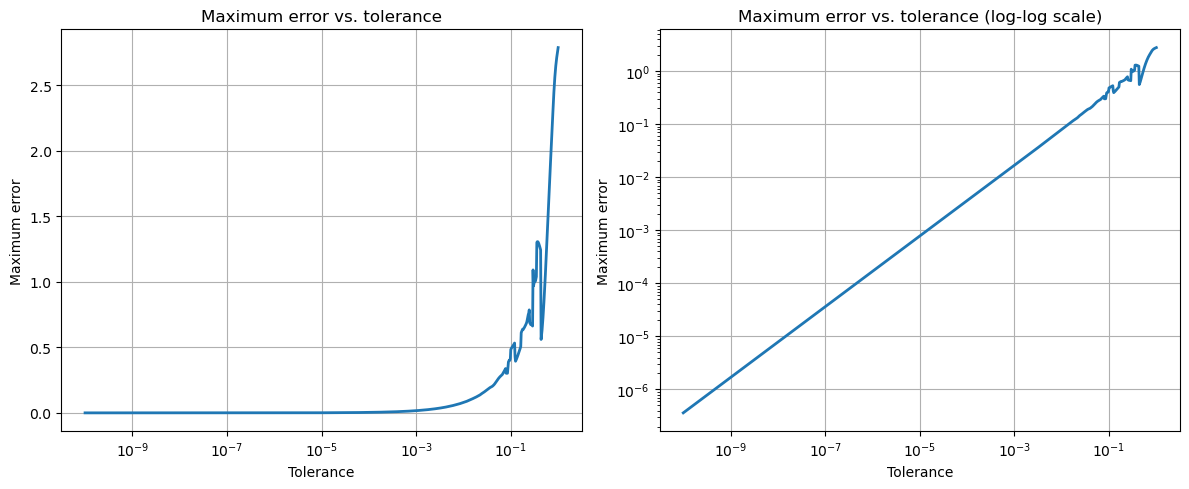

In [128]:
n = 1000
tols = np.logspace(-10, 0, n)
x_init = 0
x_end = 2 * np.pi
y_init = [0, 2]  
h0 = 1e-2
alpha = 0.8
total_error = np.zeros(n)

for i, tol in enumerate(tols):
    x_vals, y_vals, h_vals, n, m = rk(f, x_init, x_end, y_init, h0, tol, alpha)

    y1_vals = y_vals[:, 0]  
    total_error[i] = np.max(np.abs(np.sin(2*x_vals) - y1_vals))

plt.figure(figsize=(12, 5)) 

plt.subplot(1, 2, 1)  
plt.plot(tols, total_error)
plt.xlabel("Tolerance")
plt.ylabel("Maximum error")
plt.xscale("log")
plt.title("Maximum error vs. tolerance")

plt.subplot(1, 2, 2)  
plt.plot(tols, total_error)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Tolerance")
plt.ylabel("Maximum error")
plt.title("Maximum error vs. tolerance (log-log scale)")

plt.tight_layout()
plt.show()

As expected, the plot demonstrates that increasing the tolerance results in a higher maximum error. The log-log plot reveals a clear power law relationship, suggesting that the maximum error scales as $\text{error} \propto \text{tol}^p$. The linearity in the log-log representation indicates that the exponent $p$ remains relatively constant across different tolerance values.

For computational efficiency, the choice of tolerance depends on the maximum acceptable error, as the error scales linearly with the tolerance up to approximately $10^{-2}$.

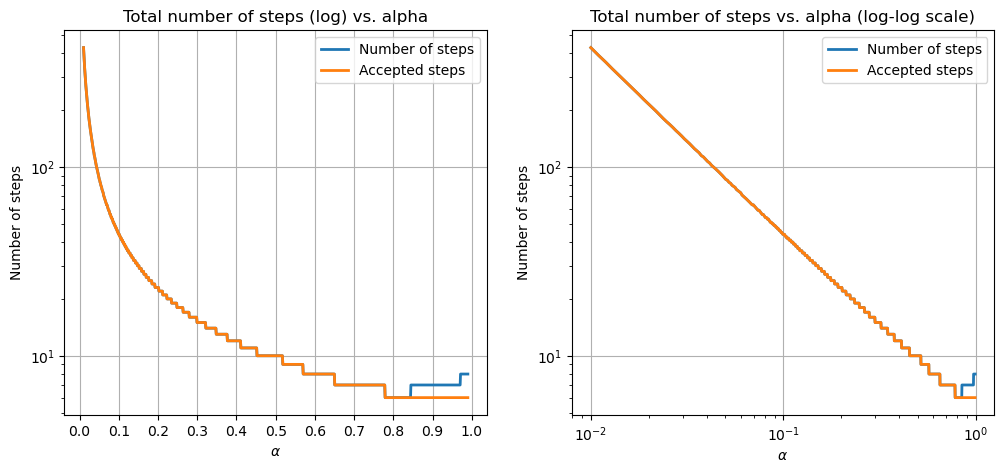

In [129]:
n = 1000
alphas = np.linspace(0.01, 0.99, n)
x_init = 0
x_end = 2 * np.pi
y_init = [0, 2]  
h0 = 1e-2
tol = 0.8
axis_list = np.linspace(0,1,11)
ns = []
acs = []

for alpha in alphas:
    x_vals, y_vals, h_vals, num_steps, accepted_steps = rk(f, x_init, x_end, y_init, h0, tol, alpha) 
    ns.append(num_steps)
    acs.append(accepted_steps)

plt.figure(figsize=(12, 5)) 

plt.subplot(1, 2, 1)  
plt.plot(alphas, ns, label = "Number of steps")
plt.plot(alphas, acs, label = "Accepted steps")
plt.yscale("log")
plt.xticks(axis_list, [f"{a:.1f}" for a in axis_list])
plt.title("Total number of steps (log) vs. alpha")
plt.ylabel("Number of steps")
plt.xlabel(r"$\alpha$")
plt.legend()

plt.subplot(1, 2, 2)  
plt.plot(alphas, ns, label = "Number of steps")
plt.plot(alphas, acs, label = "Accepted steps")
plt.xscale("log")
plt.yscale("log")
plt.title("Total number of steps vs. alpha (log-log scale)")
plt.ylabel("Number of steps")
plt.xlabel(r"$\alpha$")
plt.legend()

plt.show()

Since $\alpha$ is a pessimistic factor, we would expect a significantly larger number of steps when $\alpha$ is close to $0$, and a much smaller number of steps as $\alpha$ approaches $1$. The plot confirms these expectations, showing a sharp decrease in the number of steps as $\alpha$ increases. The linearity observed in the log-log plot further suggests a power-law relationship between the number of steps and $\alpha$.

The first plot suggests that $\alpha \approx 0.8$ is a sufficient value for achieving low computational cost while maintaining a reasonable number of steps. At this point, the decrease in the total number of steps appears to plateau, which suggests that beyond $\alpha \approx 0.8$, the reduction in computational effort is minimal compared to the earlier sharp decline in step count observed for smaller $\alpha$-values.

### 1e)

In [130]:
def secant(g, z0, z1, tol):
    max_iter = 1000

    for _ in range(max_iter):
        if np.abs(z1 - z0) < tol: 
            return z1

        z = (z0 * g(z1) - z1 * g(z0)) / (g(z1) - g(z0))

        z0, z1 = z1, z

    raise ValueError(f"Secant method did not converge after {max_iter} iterations.")

In [131]:
def g(z):
    return z + np.sin(z) + np.cos(z)

In [132]:
root = secant(g, 1, 2, 1e-3)
print(f"Root = {root:.4f}, g(root) = {g(root)} ≈ 0")

Root = -0.4566, g(root) = -5.483163367792088e-09 ≈ 0


Applying the secant method to the function $g(z) = z + \sin(z) + \cos(z)$, we observe that we are very close to finding of the root of $g(z)$.

### 1f)

In [133]:
def secant_mod(g, z0, z1, tol):
    max_iter = 1000
    roots = []

    for _ in range(max_iter):
        if np.abs(z1 - z0) < tol: 
            return roots
        z = (z0 * g(z1, x_init, x_end, y_init, h0, tol, alpha) - z1 * g(z0, x_init, x_end, y_init, h0, tol, alpha)) / (g(z1, x_init, x_end, y_init, h0, tol, alpha) - g(z0, x_init, x_end, y_init, h0, tol, alpha))
        z0, z1 = z1, z
        roots.append(z1)

    raise ValueError(f"Secant method did not converge after {max_iter} iterations.")

In [134]:

def boundary_value_solver(b, x_init, x_end, y_init, h0, tol, alpha):
    y_init[1] = b
    _, y_vals, _, _, _ = rk(f, x_init, x_end, y_init, h0, tol, alpha)
    return y_vals[-1, 0]
    

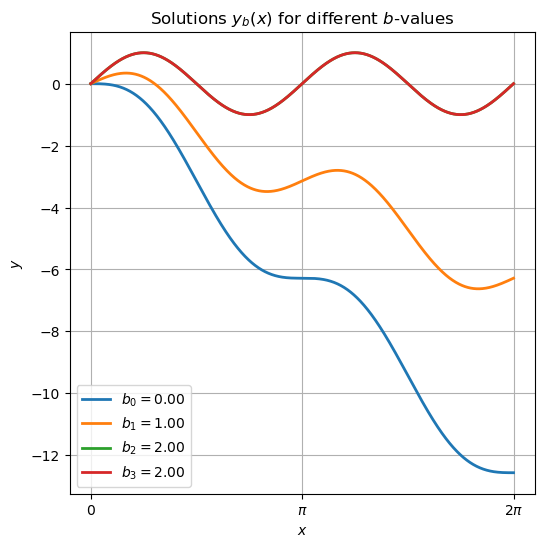

In [135]:
x_init = 0
x_end = 2 * np.pi
y_init = [0, 1]  
h0 = 1e-2
tol = 1e-7
alpha = 0.8

b0, b1 = 0, 1

roots = secant_mod(boundary_value_solver, b0, b1, tol)

for i, root in enumerate([b0, b1] + roots):
    y_init[1] = root
    x_vals, y_vals, _, _, _ = rk(f, x_init, x_end, y_init, h0, tol, alpha)

    plt.plot(x_vals, y_vals[:, 0], label=f"$b_{i} = {root:.2f}$")
  

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(rf"Solutions $y_b(x)$ for different $b$-values")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(tck.MultipleLocator(base=np.pi))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: rf"{'' if val == np.pi else int(val/np.pi)}$\pi$" if val else "0"))
plt.show()

This plot shows the solution $y(x)$ for two different $b$-values used in the secant method. 
Since the two curves overlap almost perfectly, this indicates that the method converged very quickly. 
This rapid convergence suggests that $y(2\pi)$ is nearly a linear function of $b$, allowing the secant method to find the root in very few iterations.


### 1g)

In [136]:
def f(x, y):
    return np.array([y[1], y[0] + np.sin(x)])

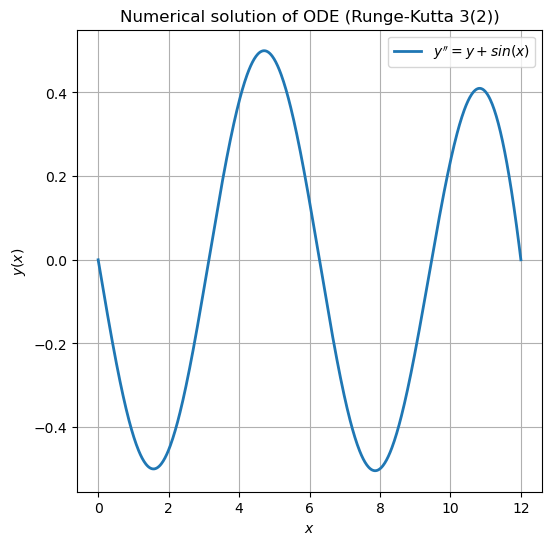

In [137]:
x_init = 0
x_end = 12
y_init = [0, 1]  
h0 = 1e-2
tol = 1e-7
alpha = 0.8

b0, b1 = 0, 1

start = time.time()
roots = secant_mod(boundary_value_solver, b0, b1, tol)
y_init[1] = roots[-1]
x_vals_rk32, y_vals_rk32, _, _, _ = rk(f, x_init, x_end, y_init, h0, tol, alpha)
end = time.time()

elapsed_time_rk32 = end - start

plt.plot(x_vals_rk32, y_vals_rk32[:, 0], label=rf"$y'' = y + sin(x)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$y(x)$")
plt.title("Numerical solution of ODE (Runge-Kutta 3(2))")
plt.legend()
plt.show()

The plot shows the solution of the ODE obtained by using Runge-Kutta 3(2).

### 1h)

In [138]:
def h(x, y):
    return np.vstack([y[1], y[0] + np.sin(x)])


In [139]:
def bc(ya, yb):
    return np.array([ya[0], yb[0]])

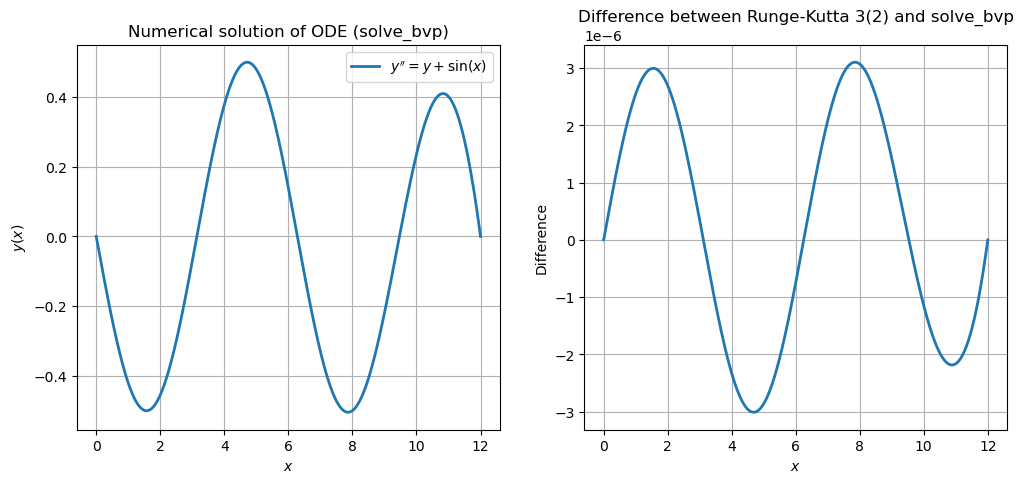

In [140]:
x_vals = np.copy(x_vals_rk32)
y_vals = np.zeros((2, x_vals.size)) 

sol = solve_bvp(h, bc, x_vals, y_vals)

y_diff = y_vals_rk32[:,0] - sol.y[0]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(sol.x, sol.y[0], label=rf"$y'' = y + \sin(x)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$y(x)$")
plt.legend()
plt.title("Numerical solution of ODE (solve_bvp)")

plt.subplot(1, 2, 2)
plt.plot(x_vals, y_diff)
plt.xlabel(r"$x$")
plt.ylabel(r"Difference")
plt.title("Difference between Runge-Kutta 3(2) and solve_bvp")
plt.show()

The plot of the numerical solution using `solve_bvp` appears smooth and follows an expected oscillatory behavior. In addition it appears very similar to the plot from excercise 1g) where the RK3(2) method was applied. However, as illustrated in the difference plot of the two methods there are some minor differences in the order of $10^{-6}$. The difference follows a periodic nature and is greatest where the solution to the ODE changes most rapidly. Furthermore, the difference plots show that the RK3(2) method exibits a greater amplitude compared to the `solve_bvp` method.


In [141]:
sum_bvp = 0
sum_rk32 = 0
n = 100

for _ in range(n):
    x_init = 0
    x_end = 12
    y_init = [0, 1]  
    h0 = 1e-2
    tol = 1e-7
    alpha = 0.8

    b0, b1 = 0, 1

    start = time.time()
    sol = solve_bvp(h, bc, x_vals, y_vals)
    end = time.time()

    elapsed_time_bvp = end - start

    start = time.time()
    roots = secant_mod(boundary_value_solver, b0, b1, tol)
    y_init[1] = roots[-1]
    x_vals_rk32, y_vals_rk32, _, _, _ = rk(f, x_init, x_end, y_init, h0, tol, alpha)
    end = time.time()

    elapsed_time_rk32 = end - start
    
    sum_bvp += elapsed_time_bvp
    sum_rk32 += elapsed_time_rk32


print(f"Number of iterations: {n}")
print(f"Average elapsed time for RK3(2): {sum_rk32/n:.6f}s")
print(f"Average elapsed time for solve_bvp: {sum_bvp/n:.6f}s")
print(f"solve_bvp is {(sum_rk32/n)/(sum_bvp/n):.0f} times faster RK3(2)")

Number of iterations: 100
Average elapsed time for RK3(2): 0.793036s
Average elapsed time for solve_bvp: 0.001846s
solve_bvp is 430 times faster RK3(2)



Since `solve_bvp` is specifically designed for boundary value problems, we expect it to be significantly more efficient than the Runge-Kutta 3(2) method. Our results confirm this, as `solve_bvp` computes the solution approximately $430$ times (100 iterations) faster while maintaining similar accuracy. Given this substantial computational speedup with no significant difference in accuracy, `solve_bvp` is the preferred method.

## Problem 2

### Global variables

In [142]:
delta = 0.01
zeta = 3
l = 1
I = np.identity(2)

$$\hat{g}(x, \varepsilon) = \begin{pmatrix} 2\mathbf{N}(x, \varepsilon) - \mathbf{I} && 2\mathbf{N}(x, \varepsilon)\mathbf{\gamma}(x, \varepsilon) \\ -2\mathbf{\tilde{N}}(x, \varepsilon)\mathbf{\tilde{\gamma}}(x, \varepsilon) && -2\mathbf{\tilde{N}}(x, \varepsilon) + \mathbf{I} \end{pmatrix},$$

where $\mathbf{N}$, $\mathbf{\tilde{N}}$, $\mathbf{I}$ (identity matrix), $\mathbf{\gamma}$ and $\mathbf{\tilde{\gamma}}$ are $2 \times 2$ matrices:

$$
\mathbf{N}(x, \varepsilon) = [\mathbf{I} - \mathbf{\gamma}(x, \varepsilon)\mathbf{\tilde{\gamma}}(x, \varepsilon)]^{-1}
$$ 
$$
\mathbf{\tilde{N}}(x, \varepsilon) = [\mathbf{I} - \mathbf{\tilde{\gamma}}(x, \varepsilon)\mathbf{\gamma}(x, \varepsilon)]^{-1}
$$
$\mathbf{\gamma}(x, \varepsilon)$ and $\mathbf{\tilde{\gamma}}(x, \varepsilon)$ are known as Riccati matrices, and their derivatives are denoted as $\mathbf{\omega}(x, \varepsilon)$ and $\mathbf{\tilde{\omega}}(x, \varepsilon).$

### 2a)

In [143]:
def matrix_to_vector(M):
    return np.concatenate((M.real.ravel(), M.imag.ravel()))

def vector_to_matrix(m):
    size = int(len(m) // 4) 
    M_r = m[:size**2].reshape((size, size)) 
    M_i = m[size**2:].reshape((size, size))  

    return M_r + 1j * M_i

matrix = np.array([[1+10j, 2+20j],
                   [3+30j, 4+40j]])

print("Original matrix: ")
print(matrix)

m = matrix_to_vector(matrix)

print("\nVector representation: ")
print(m)

M = vector_to_matrix(m)
print("\nReconstructed matrix: ")
print(M)

assert np.allclose(matrix, M)


Original matrix: 
[[1.+10.j 2.+20.j]
 [3.+30.j 4.+40.j]]

Vector representation: 
[ 1.  2.  3.  4. 10. 20. 30. 40.]

Reconstructed matrix: 
[[1.+10.j 2.+20.j]
 [3.+30.j 4.+40.j]]


By applying `assert np.allclose(matrix, M)` we ensure that the transformations work correctly – we check if `matrix` is equal to `M`, but we allow for small numerical deviations which can occur when working with complex numbers (which `np.allclose()` handles). 

### 2b)

In [144]:
a = np.array([1, 2, 3, 4, 5, 6, 7, 8])
b = np.array([9, 10, 11, 12, 13, 14, 15, 16])
c = np.array([17, 18, 19, 20, 21, 22, 23, 24])
d = np.array([25, 26, 27, 28, 29, 30, 31, 32])

def concatenate_vectors(a, b, c, d):
    return np.concatenate((a, b, c, d), axis=0)

def split_vector(v):
    return np.split(v, 4)

v = concatenate_vectors(a, b, c, d)

m1, m2, m3, m4 = split_vector(v)

print("Original matrices: ")
print(a)
print(b)
print(c)
print(d)

print("\nConcatenate representation: ")
print(v)

print("\nReconstructed matrices: ")
print(m1)
print(m2)
print(m3)
print(m4)

assert np.array_equal(a, m1)
assert np.array_equal(b, m2)
assert np.array_equal(c, m3)
assert np.array_equal(d, m4)

Original matrices: 
[1 2 3 4 5 6 7 8]
[ 9 10 11 12 13 14 15 16]
[17 18 19 20 21 22 23 24]
[25 26 27 28 29 30 31 32]

Concatenate representation: 
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32]

Reconstructed matrices: 
[1 2 3 4 5 6 7 8]
[ 9 10 11 12 13 14 15 16]
[17 18 19 20 21 22 23 24]
[25 26 27 28 29 30 31 32]


With `assert np.array_equal()` we make sure that the vectors are equal.

### 2c)

In [145]:
def matrices_to_vector(gamma, gamma_tilde, omega, omega_tilde):
    return concatenate_vectors(matrix_to_vector(gamma), matrix_to_vector(gamma_tilde), matrix_to_vector(omega), matrix_to_vector(omega_tilde))

def vector_to_matrices(v):
    gamma_vector, gamma_tilde_vector, omega_vector, omega_tilde_vector = split_vector(v)
    return vector_to_matrix(gamma_vector), vector_to_matrix(gamma_tilde_vector), vector_to_matrix(omega_vector), vector_to_matrix(omega_tilde_vector)

A = np.array([[1 + 10j, 2 + 20j],
             [3 + 30j, 4 + 40j]])

B = np.array([[5, 6],
             [7, 8]])

C = np.array([[9, 10],
             [11, 12]])

D = np.array([[13, 14],
             [15, 16]])

v = matrices_to_vector(A, B, C, D)

print("Vector of matrices A, B, C, D:")
print(v, "\n")

E, F, G, H = vector_to_matrices(v)

print("\nMatrices from vector:")
print(E, "\n")
print(F, "\n")
print(G, "\n")
print(H, "\n")



Vector of matrices A, B, C, D:
[ 1.  2.  3.  4. 10. 20. 30. 40.  5.  6.  7.  8.  0.  0.  0.  0.  9. 10.
 11. 12.  0.  0.  0.  0. 13. 14. 15. 16.  0.  0.  0.  0.] 


Matrices from vector:
[[1.+10.j 2.+20.j]
 [3.+30.j 4.+40.j]] 

[[5.+0.j 6.+0.j]
 [7.+0.j 8.+0.j]] 

[[ 9.+0.j 10.+0.j]
 [11.+0.j 12.+0.j]] 

[[13.+0.j 14.+0.j]
 [15.+0.j 16.+0.j]] 



### 2d)

In [146]:
def derivate_of_v(v, epsilon):
    gamma, gamma_tilde, omega, omega_tilde = vector_to_matrices(v)

    d_gamma = np.copy(omega)
    d_gamma_tilde = np.copy(omega_tilde)

    N = np.linalg.inv(I - gamma @ gamma_tilde)
    N_tilde = np.linalg.inv(I - gamma_tilde @ gamma)

    d_omega = -2j * (epsilon + 1j*delta) * gamma - 2 * omega @ N_tilde @ gamma_tilde @ omega
    d_omega_tilde = -2j * (epsilon + 1j*delta) * gamma_tilde - 2 * omega_tilde @ N @ gamma @ omega_tilde

    return matrices_to_vector(d_gamma, d_gamma_tilde, d_omega, d_omega_tilde)

### 2e)

In [147]:
def fun_solve_bvp(x, vec, epsilon):
    m = vec.shape[1]
    d_vec = np.zeros_like(vec)

    for i in range(m):
        d_vec[:, i] = derivate_of_v(vec[:, i], epsilon)
    
    return d_vec


### 2f)

In [148]:
def bc_solve_bvp(v_left, v_right):
    gamma_l, gamma_tilde_l, omega_l, omega_tilde_l = vector_to_matrices(v_left)
    gamma_r, gamma_tilde_r, omega_r, omega_tilde_r = vector_to_matrices(v_right)

    zero_vec = np.zeros((2,2))          #Interfaced Riccati matrices set to zero

    N_L = np.linalg.inv(I - zero_vec @ zero_vec)
    N_tilde_L = np.linalg.inv(I - zero_vec @ zero_vec)
    N_R = np.linalg.inv(I - zero_vec @ zero_vec)
    N_tilde_R = np.linalg.inv(I - zero_vec @ zero_vec)

    bc_left_omega = omega_l + (1 / (zeta * l)) * (I - gamma_l @ zero_vec) @ N_L @ (zero_vec - gamma_l)
    bc_left_omega_tilde = omega_tilde_l + (1 / (zeta * l)) * (I - gamma_tilde_l @ zero_vec) @ N_tilde_L @ (zero_vec - gamma_tilde_l)

    bc_right_omega = omega_r - (1 / (zeta * l)) * (I - gamma_r @ zero_vec) @ N_R @ (zero_vec - gamma_r)
    bc_right_omega_tilde = omega_tilde_r - (1 / (zeta * l)) * (I - gamma_tilde_r @ zero_vec) @ N_tilde_R @ (zero_vec - gamma_tilde_r)

    bc_vector = matrices_to_vector(bc_left_omega, bc_left_omega_tilde, bc_right_omega, bc_right_omega_tilde)

    return bc_vector

### 2g)

In [149]:
m = 101

x = np.linspace(0, 1, m)
y_init = np.zeros((32, m))

epsilons = [0, 1, 2]
solutions = {}
times = []
for epsilon in epsilons:

    sol = solve_bvp(lambda x, vec: fun_solve_bvp(x, vec, epsilon), 
                    bc_solve_bvp, x, y_init)

    solutions[epsilon] = sol.y  

    print(f"Epsilon = {epsilon}, deviation from zero: {np.max(sol.y)}")


Epsilon = 0, deviation from zero: 0.0
Epsilon = 1, deviation from zero: 0.0
Epsilon = 2, deviation from zero: 0.0


As expected all the values are zero.

### 2h)

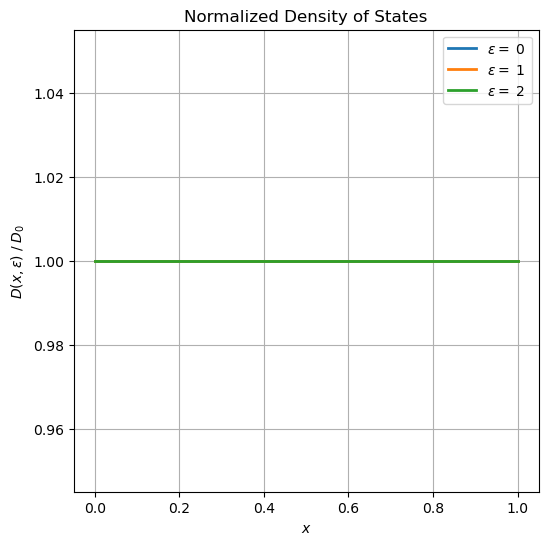

In [150]:
def compute_density_of_states(sol, x, epsilons):

    rho_3 = np.block([[I, np.zeros((2, 2))], [np.zeros((2, 2)), -I]])  
    D_over_D0 = {}

    for epsilon in epsilons:
        y = sol[epsilon]  
        m = y.shape[1]  
        D_vals = np.zeros(m) 

        for i in range(m):
            gamma, gamma_tilde, _, _ = vector_to_matrices(y[:, i])

            N = np.linalg.inv(I - gamma @ gamma_tilde)
            N_tilde = np.linalg.inv(I - gamma_tilde @ gamma)

        
            g_hat = np.block([
                [2 * N - I, 2 * N @ gamma],
                [-2 * N_tilde @ gamma_tilde, -2 * N_tilde + I]
            ])

    
            D_vals[i] = np.real(np.trace(rho_3 @ g_hat)) / 4

        D_over_D0[epsilon] = D_vals  

    return D_over_D0

D_over_D0 = compute_density_of_states(solutions, x, epsilons)

for epsilon in epsilons:
    plt.plot(x, D_over_D0[epsilon], label=rf"$ \varepsilon =$ {epsilon}")

plt.xlabel(r"$x$")
plt.ylabel(r"$D(x, \varepsilon) \; / \; D_0$")
plt.title("Normalized Density of States")
plt.legend()
plt.show()

As expected, the normalized density of states $D(x, \varepsilon) / D_0$ remains 1 throughout the system. This is because we are dealing with a normal metal, where the density of states is homogeneous and does not depend on position or energy. Since no superconducting or other modifying effects are present, the result follows directly from the definition.  

### 2i)

In [151]:
def compute_riccati_superconductor(epsilon, phi_L, phi_R):
    theta = np.arctanh(1 / (epsilon + 1j * delta))
    s_plus = np.sinh(theta)
    s_minus = np.sinh(-theta)
    c_plus = np.cosh(theta)
    c_minus = np.cosh(-theta)

    gamma_L = np.array([[0, s_plus / (1 + c_plus)], 
                      [s_minus / (1 + c_minus), 0]])*np.e**(1j*phi_L)
    
    gamma_tilde_L = np.array([[0, s_minus / (1 + c_minus)], 
                      [s_plus / (1 + c_plus), 0]])*np.e**(-1j*phi_L)
    
    gamma_R = np.array([[0, s_plus / (1 + c_plus)], 
                      [s_minus / (1 + c_minus), 0]])*np.e**(1j*phi_R)
    
    gamma_tilde_R = np.array([[0, s_minus / (1 + c_minus)], 
                      [s_plus / (1 + c_plus), 0]])*np.e**(-1j*phi_R)

    return gamma_L, gamma_tilde_L, gamma_R, gamma_tilde_R

def bc_superconductor(v_left, v_right, epsilon, phi_L, phi_R):

    gamma_l, gamma_tilde_l, omega_l, omega_tilde_l = vector_to_matrices(v_left)
    gamma_r, gamma_tilde_r, omega_r, omega_tilde_r = vector_to_matrices(v_right)

    gamma_L, gamma_tilde_L, gamma_R, gamma_tilde_R = compute_riccati_superconductor(epsilon, phi_L, phi_R)
    N_L = np.linalg.inv(I - gamma_L @ gamma_tilde_L)
    N_tilde_L = np.linalg.inv(I - gamma_tilde_L @ gamma_L)
    N_R = np.linalg.inv(I - gamma_R @ gamma_tilde_R)
    N_tilde_R = np.linalg.inv(I - gamma_tilde_R @ gamma_R)

    bc_left_omega = omega_l + (1 / (zeta * l)) * (I - gamma_l @ gamma_tilde_L) @ N_L @ (gamma_L - gamma_l)
    bc_left_omega_tilde = omega_tilde_l + (1 / (zeta * l)) * (I - gamma_tilde_l @ gamma_L) @ N_tilde_L @ (gamma_tilde_L - gamma_tilde_l)

    bc_right_omega = omega_r - (1 / (zeta*l)) * (I - gamma_r @ gamma_tilde_R) @ N_R @ (gamma_R - gamma_r)
    bc_right_omega_tilde = omega_tilde_r - (1 / (zeta*l)) * (I - gamma_tilde_r @ gamma_R) @ N_tilde_R @ (gamma_tilde_R - gamma_tilde_r)

    bc_vector = matrices_to_vector(bc_left_omega, bc_left_omega_tilde, bc_right_omega, bc_right_omega_tilde)

    return bc_vector

### 2j)

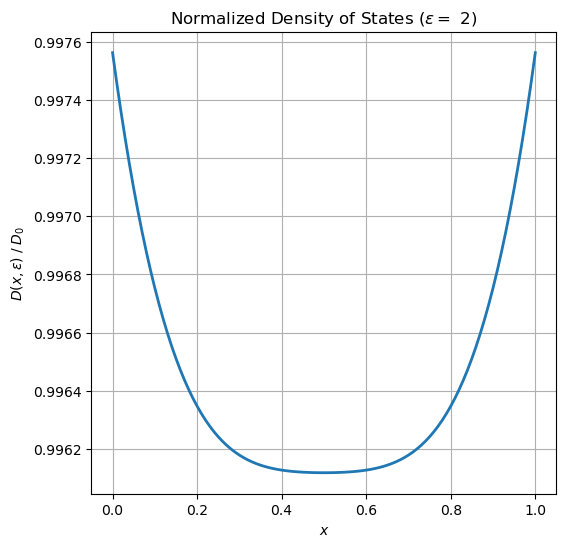

In [152]:
m = 101

x = np.linspace(0, 1, m)
y_init = np.zeros((32, m))

epsilon = 2

sol = solve_bvp(lambda x, vec: fun_solve_bvp(x, vec, epsilon), 
                lambda v_left, v_right: bc_superconductor(v_left, v_right, epsilon, 0, 0), 
                x, y_init)


D_over_D0 = compute_density_of_states({epsilon: sol.y}, x, [epsilon])

plt.plot(x, D_over_D0[epsilon])
plt.xlabel(r"$x$")
plt.ylabel(r"$D(x, \varepsilon) \; / \; D_0$")
plt.title(rf"Normalized Density of States ($\varepsilon = $ {epsilon})")
plt.show()

In Figure 1 we see that with $\varepsilon = 2$, the density of states, $D(x, \varepsilon) \; / \; D_0$, is slightly greater than 1 in the superconducters. Therefore we also expect the density of states in the normal metal not to differ greatly from 1, as in exercise 2h). 

The proximity effect leads to Cooper pairs "leaking" into the normal metal. These occupy some of the available states, leading to a slight decrease in the density of states. By symmetry, this effect is strongest around the center.

### 2k)

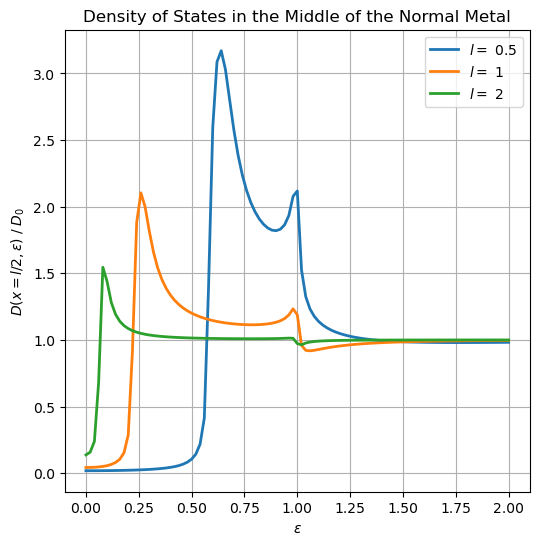

In [153]:
epsilons = np.linspace(0, 2, 101)
ls = [0.5, 1, 2]
m = 101
density_of_states = {}

for l in ls:
    x = np.linspace(0, l, m)
    y_init = np.zeros((32, m))

    solutions = {}

    for i, epsilon in enumerate(reversed(epsilons)):
        sol = solve_bvp(lambda x, vec: fun_solve_bvp(x, vec, epsilon), 
                        lambda v_left, v_right: bc_superconductor(v_left, v_right, epsilon, 0, 0), 
                        x, y_init)
        solutions[epsilon] = sol.y
        y_init = sol.sol(x)


    middle_index = m // 2  
    D_epsilon = []

    for epsilon in epsilons:
        D = compute_density_of_states(solutions, x, [epsilon])
        D_epsilon.append(D[epsilon][middle_index])  

    density_of_states[l] = D_epsilon  


for l in ls:
    plt.plot(epsilons, density_of_states[l], label=rf"$l =$ {l}")

plt.xlabel(r"$\varepsilon$")
plt.ylabel(r"$D(x=l/2, \varepsilon) \; / \; D_0$")
plt.title("Density of States in the Middle of the Normal Metal")
plt.legend()
plt.show()

As previously shown, for larger $\varepsilon$, the density of states remains almost unaffected in the middle of the metal. However, for smaller energies, we observe significant deviations due to the proximity effect, where superconducting correlations extend into the normal metal.  

For short metal lengths ($l = 0.5$), a clear minigap forms, preventing single-particle states from existing at low energies. As the metal length increases, the minigap gradually shrinks and disappears. For $l = 2$, the density of states closely resembles that of a normal metal, confirming that superconducting correlations decay over longer distances. Thus, the proximity effect is strongest for short metals, while longer metals behave more like conventional conductors with an unaltered density of states. Around $\varepsilon = 1$ we observe a peak, which occurs due to the minigap. 

### 2l)

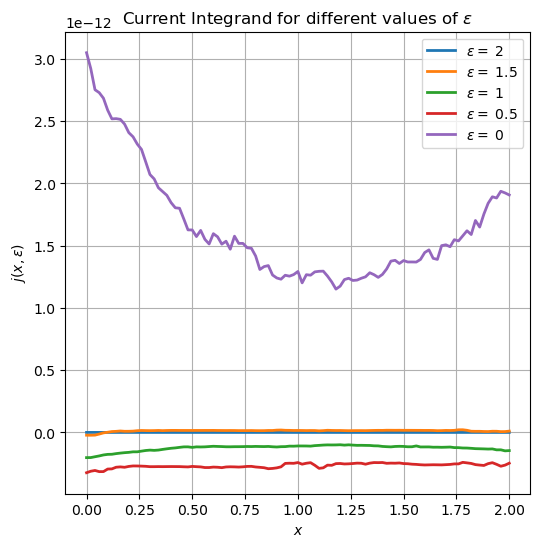

In [154]:
rho_3 = np.block([[I, np.zeros((2, 2))], [np.zeros((2, 2)), -I]])
l = 1
epsilons = [2, 1.5, 1, 0.5, 0]
m = 101
xs = np.linspace(0, l, m)
sols = solutions


def compute_green_function(gamma, gamma_tilde, omega, omega_tilde):
    N = np.linalg.inv(I - gamma @ gamma_tilde)
    N_tilde = np.linalg.inv(I - gamma_tilde @ gamma)
    d_N = N @ (omega @ gamma_tilde + gamma @ omega_tilde) @ N
    d_N_tilde = N_tilde @ (omega_tilde @ gamma + gamma_tilde @ omega) @ N_tilde

    g = np.block([
        [2*N - I, 2*N @ gamma],
        [-2*N_tilde @ gamma_tilde, -2*N_tilde + I]
    ])

    d_g = 2*np.block([
        [d_N, N @ omega + d_N @ gamma],
        [-N_tilde @ omega_tilde - d_N_tilde @ gamma_tilde, -d_N_tilde]
    ])

    return g, d_g

def compute_current_integrand(solutions, epsilons, xs):
    j = np.zeros((len(epsilons), len(xs)))
    for n, epsilon in enumerate(epsilons):
        for i, x in enumerate(xs):
            gamma, gamma_tilde, omega, omega_tilde = vector_to_matrices(solutions[epsilon][:, i])
            g, d_g = compute_green_function(gamma, gamma_tilde, omega, omega_tilde)

            j[n][i] = np.real(np.trace(rho_3 @ (g @ d_g - d_g @ g)))

    return j

j = compute_current_integrand(sols, epsilons, x)


for i, epsilon in enumerate(epsilons):
    plt.plot(x, j[i], label=rf"$\varepsilon =$ {epsilon}")

plt.xlabel(r"$x$")
plt.ylabel(r"$j(x, \varepsilon)$")
plt.title(r"Current Integrand for different values of $\varepsilon$")
plt.legend()
plt.show()

We expect to see a current integrand equalt to zero, and we observe that current integrand is very close to zero for all values of $\varepsilon$. The small deviation ($<10^{-10}$) is most likely due to numerical unstabilities. 

### 2m)

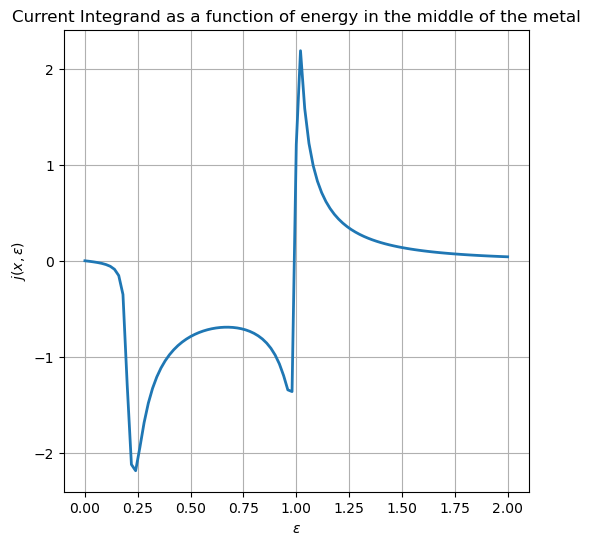

Sum of standard deviation across positions: 2.42e-04, with max variance: 7.82e-10


In [155]:
epsilons = np.linspace(0, 2, 101)
l = 1
m = 101
x = np.linspace(0, l, m)
y_init = np.zeros((32, m))

for i, epsilon in enumerate(epsilons):

    sol = solve_bvp(lambda x, vec: fun_solve_bvp(x, vec, epsilon), 
                    lambda v_left, v_right: bc_superconductor(v_left, v_right, epsilon, phi_L=1, phi_R=0), 
                    x, y_init)
    solutions[epsilon] = sol.y
    y_init = sol.sol(x)

sols = solutions

j = compute_current_integrand(sols, epsilons, x)

middle_values = j[:, m // 2]


plt.plot(epsilons, middle_values)
plt.xlabel(r"$\varepsilon$")
plt.ylabel(r"$j(x, \varepsilon)$")
plt.title("Current Integrand as a function of energy in the middle of the metal")
plt.show()

print(f"Sum of standard deviation across positions: {np.sum(np.std(j, axis=1)):.2e}, with max variance: {np.max(np.var(j, axis=1)):.2e}")

In exercise 2l), where no phase difference was present between the superconductors, we observed that the current integrand $j(x, \varepsilon)$ was approximately zero everywhere. With a phase difference of $\phi_L = 1$ and $\phi_R = 0$, we see that $j(x, \varepsilon)$ varies significantly as a function of $\varepsilon$, confirming the presence of a supercurrent through the normal metal.

We obtain a low standard deviation and variance across all positions, meaning the current integrand is conserved as a function of position, and the deviations is due to the numerical unstability (as discussed previously).

The first dip at $\varepsilon \approx 0.25$ corresponds to the minigap for $l = 1$ from exercise 2k). This follows the expectation that higher density of states correlates to a greater current. The same follows for the small dip prior to $\varepsilon = 1$ as seen i exercise 2k). The peak at $\varepsilon = 1$ corresponds to the superconducting gap from Figure 1. As expected, when $\varepsilon$ becomes greater than $\approx 1.25$, the superconductors behave as normal metals, and the current integrand approaches $0$.

From further investigations the dips and peak are located in the same positions when the phase difference is altered. The amplitudes and signs vary periodically.

### 2n)

In [156]:
l = 1
m = 101
epsilons = np.linspace(0, 2, m)
x = np.linspace(0, l, m)
y_init = np.zeros((32, m))
phi_L = np.linspace(0, 2*np.pi, 10)
phi_R = 0

solutions = np.zeros((len(phi_L), len(epsilons), 32, m))

for i, phi_l in enumerate(phi_L):
    y_init = np.zeros((32, m))
    for j, epsilon in enumerate(epsilons):
        sol = solve_bvp(lambda x, vec: fun_solve_bvp(x, vec, epsilon), 
                        lambda v_left, v_right: bc_superconductor(v_left, v_right, epsilon, phi_L=phi_l, phi_R=0), 
                        x, y_init)
        
        solutions[i, j] = sol.y
        y_init = sol.y
        


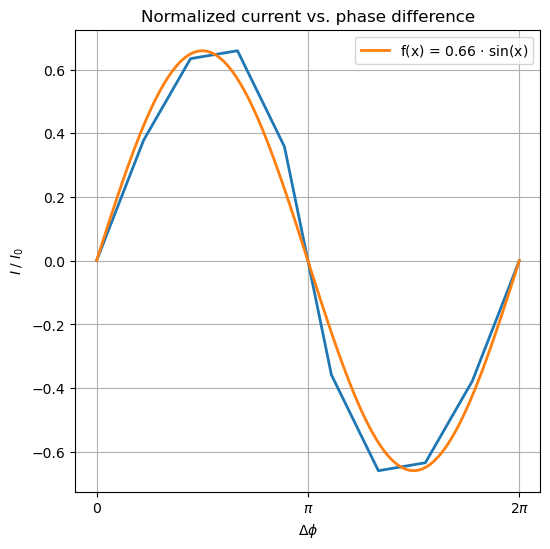

In [157]:
current = np.zeros((len(phi_L), len(epsilons), len(x)))

for i in range(len(phi_L)):
    sols = {}
    for j, epsilon in enumerate(epsilons):
        sols[epsilon] = solutions[i][j][:][:]
    current[i][:][:] = compute_current_integrand(sols, epsilons, x)

integrals_per_phase = np.zeros(current.shape[0]) 
for i in range(current.shape[0]):  
    integrals_per_phase[i] = -simpson(current[i, :, :], epsilons, axis=0).mean()    #As the current integrand varies minimaly with x, we take the mean of the j(x,e) values 
    
sinusAmplitude = integrals_per_phase.max()
sinusFunc = lambda x: sinusAmplitude * np.sin(x)
x = np.linspace(0, 2*np.pi, 101)

plt.plot(phi_L, integrals_per_phase)
plt.plot(x, sinusFunc(x), label = fr'f(x) = {sinusAmplitude:.2f} $\cdot$ sin(x)')
plt.xlabel(r"$\Delta\phi$")
plt.ylabel(r"$I \; / \; I_0$")
plt.title("Normalized current vs. phase difference")
ax = plt.gca()
ax.xaxis.set_major_locator(tck.MultipleLocator(base=np.pi))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: rf"{'' if val == np.pi else int(val/np.pi)}$\pi$" if val else "0"))
plt.legend()
plt.show()

We observe that $I / I_0$ follows a sinusoidal path, as expected from the Josephson effect. 
The maximum current occurs around $\Delta \phi \approx \pi/2$, the current reverses direction at $\Delta \phi = \pi$ and the minimum appears at $\Delta \phi \approx 3\pi/2$. 
This aligns with the Josephson current-phase relation:

$$I(\Delta \phi) = I_c \sin(\Delta \phi)$$

The normalized amplitude $I_c / I_0$ is approximately $0.66$.

Due to the limited number of phase points, the curve appears somewhat discrete. Increasing the resolution would yield a smoother sinusoidal shape but requires significantly more computation time.

Overall, the results confirm the sinusoidal dependence of $I / I_0$ on the phase difference, demonstrating the key behavior of the Josephson effect.
